In [13]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [14]:
TARGET = 'addicted_label'
ID_COL = 'id'

DATA_DIR = (
    "/kaggle/input/playground-series-s6e8"
    if os.path.exists("/kaggle/input/playground-series-s6e8")
    else "."
)
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Train Shape: {train.shape} | Test Shape: {test.shape}")

Train Shape: (691369, 14) | Test Shape: (296302, 13)


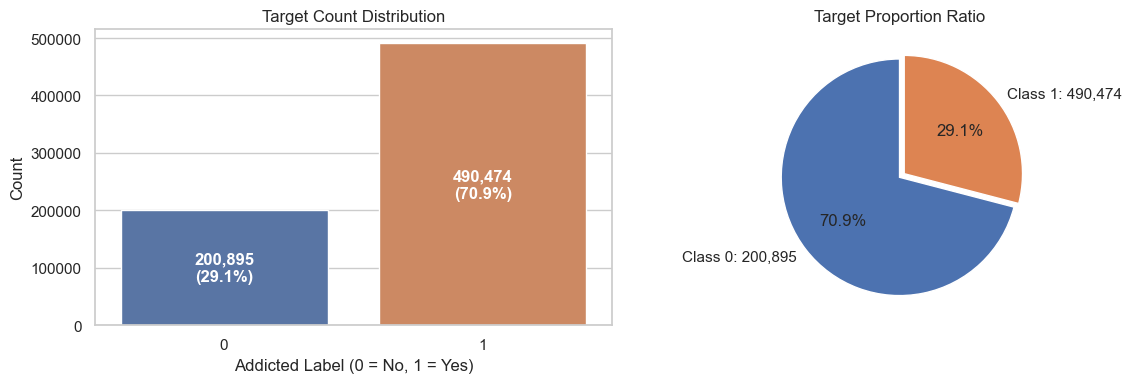

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count bar plot
sns.countplot(data=train, x=TARGET, ax=ax[0], palette=["#4C72B0", "#DD8452"])
ax[0].set_title("Target Count Distribution")
ax[0].set_xlabel("Addicted Label (0 = No, 1 = Yes)")
ax[0].set_ylabel("Count")

for p in ax[0].patches:
  count = int(p.get_height())
  pct = count / len(train) * 100
  ax[0].annotate(
      f"{count:,}\n({pct:.1f}%)",
      (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
      ha="center",
      va="center",
      color="white",
      fontweight="bold",
  )

# Pie chart for ratio visual
target_counts = train[TARGET].value_counts()
ax[1].pie(
    target_counts,
    labels=[f"Class 0: {target_counts[0]:,}", f"Class 1: {target_counts[1]:,}"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    explode=(0, 0.05),
)
ax[1].set_title("Target Proportion Ratio")

plt.tight_layout()
plt.show()

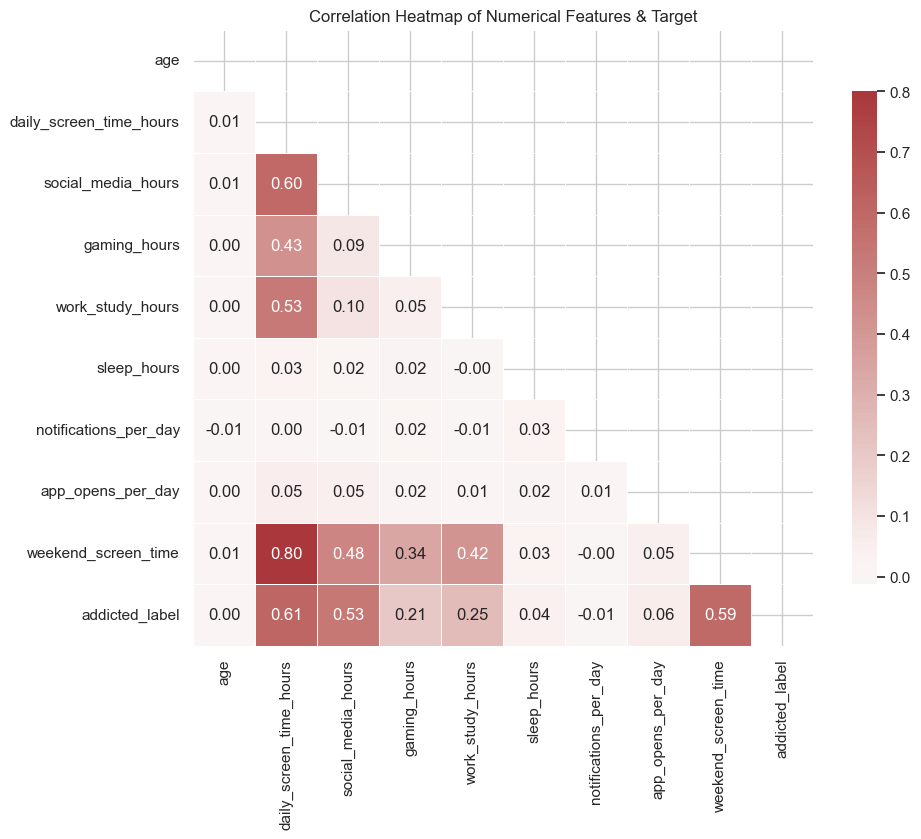

In [16]:
# Extract numerical columns safely as a list
num_cols = (
    train.select_dtypes(include=[np.number])
    .drop(columns=[ID_COL, TARGET], errors='ignore')
    .columns.tolist()
)

# Prepare columns for correlation matrix
cols_to_corr = list(num_cols)
if TARGET in train.columns and TARGET not in cols_to_corr:
  cols_to_corr.append(TARGET)

if len(cols_to_corr) > 1:
  plt.figure(figsize=(10, 8))
  corr_matrix = train[cols_to_corr].corr()

  # Mask upper triangle for clean reading
  mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

  sns.heatmap(
      corr_matrix,
      mask=mask,
      annot=True,
      fmt='.2f',
      cmap='vlag',
      center=0,
      linewidths=0.5,
      cbar_kws={'shrink': 0.8},
  )
  plt.title('Correlation Heatmap of Numerical Features & Target')
  plt.show()
else:
  print('Not enough numerical columns found for a correlation matrix.')

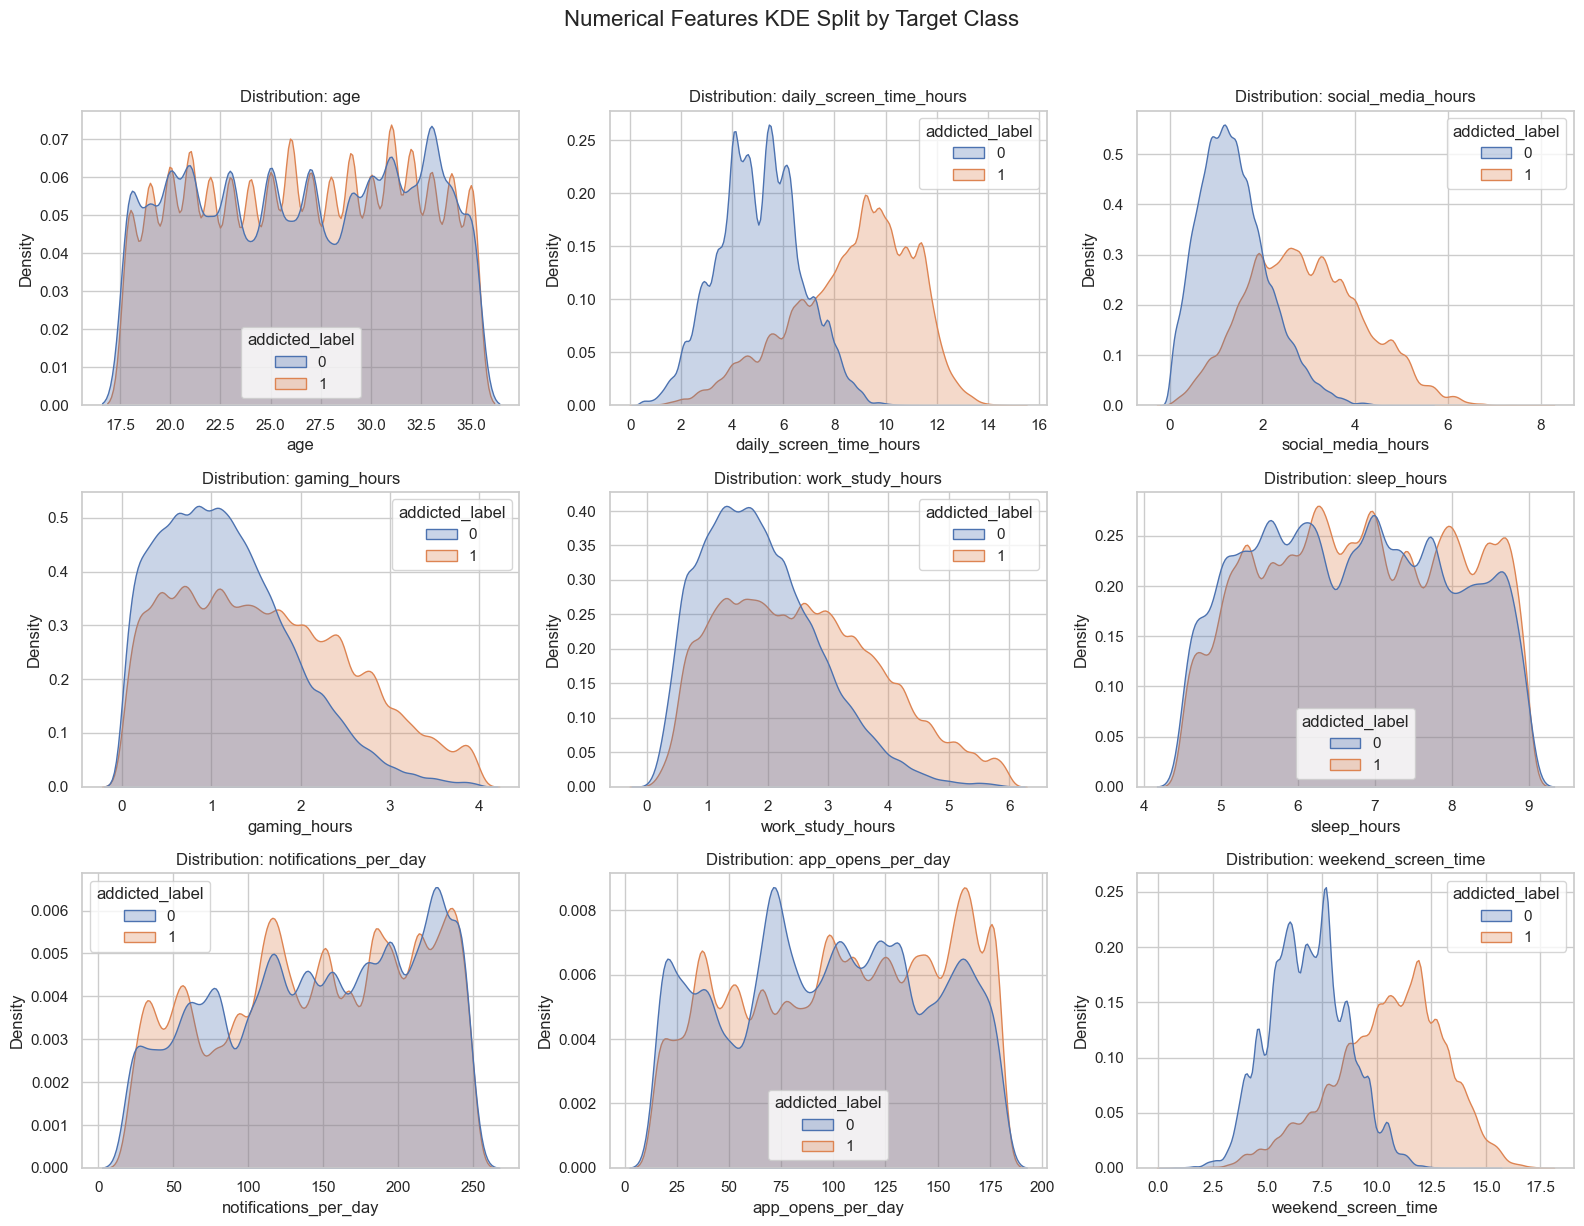

In [17]:
if len(num_cols) > 0:
  n_cols = 3
  n_rows = int(np.ceil(len(num_cols) / n_cols))

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
  axes = axes.flatten()

  for idx, col in enumerate(num_cols):
    sns.kdeplot(
        data=train,
        x=col,
        hue=TARGET,
        common_norm=False,
        fill=True,
        alpha=0.3,
        palette=["#4C72B0", "#DD8452"],
        ax=axes[idx],
    )
    axes[idx].set_title(f"Distribution: {col}")

  # Hide unused subplots
  for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

  plt.suptitle(
      "Numerical Features KDE Split by Target Class", y=1.02, fontsize=16
  )
  plt.tight_layout()
  plt.show()

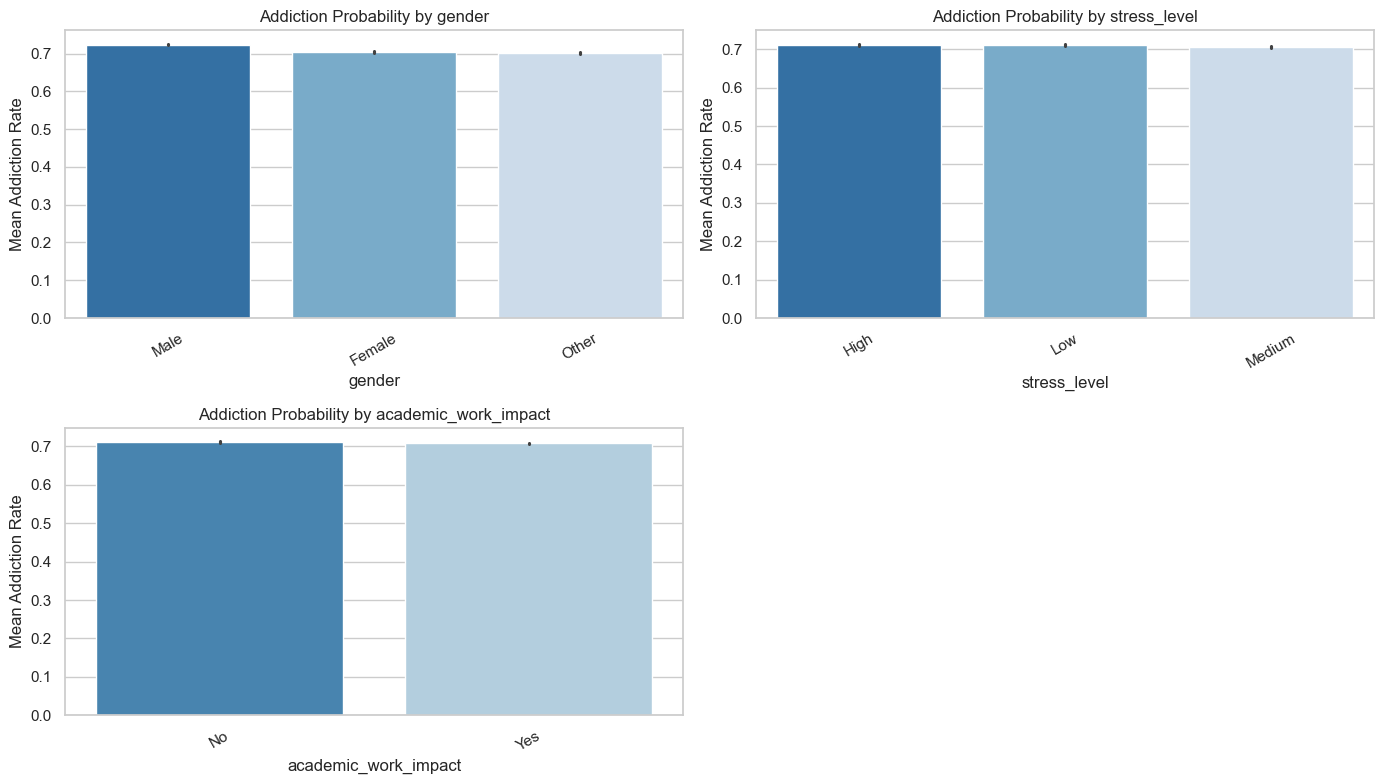

In [18]:
# Auto-detect categorical columns (excluding ID and TARGET)
cat_cols = (
    train.select_dtypes(include=["object", "category"])
    .drop(columns=[ID_COL, TARGET], errors="ignore")
    .columns.tolist()
)

if len(cat_cols) > 0:
  n_cols = 2
  n_rows = int(np.ceil(len(cat_cols) / n_cols))

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
  # Handle case where there's only 1 categorical column
  axes = np.array([axes]).flatten() if n_rows == 1 and n_cols == 1 else np.array(axes).flatten()

  for idx, col in enumerate(cat_cols):
    cat_order = train.groupby(col)[TARGET].mean().sort_values(ascending=False)

    sns.barplot(
        data=train,
        x=col,
        y=TARGET,
        order=cat_order.index,
        palette="Blues_r",
        ax=axes[idx],
    )
    axes[idx].set_title(f"Addiction Probability by {col}")
    axes[idx].set_ylabel("Mean Addiction Rate")
    axes[idx].tick_params(axis="x", rotation=30)

  # Remove empty subplot spaces
  for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()
else:
  print("No categorical columns detected in the dataset.")

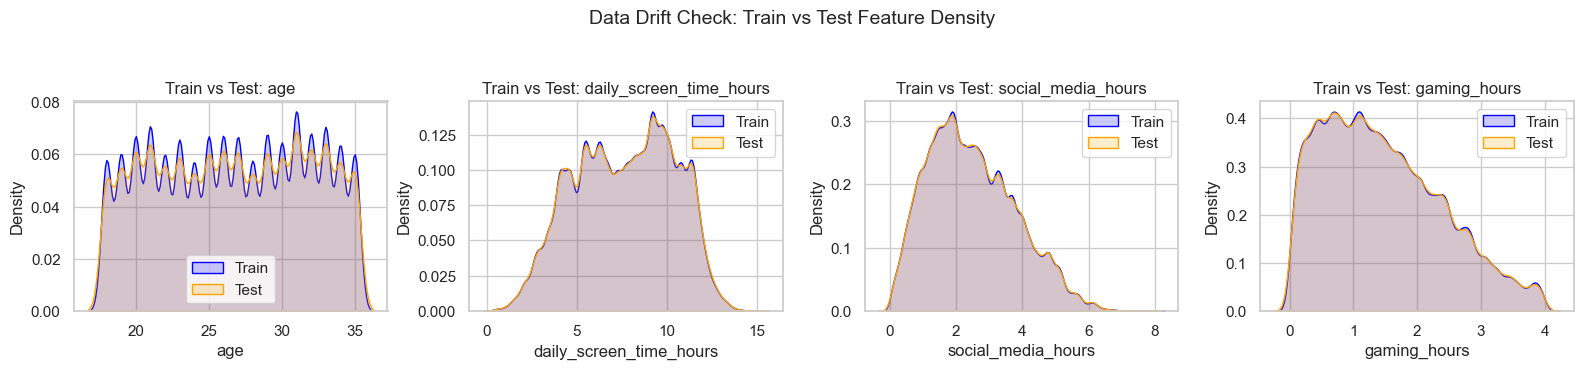

In [19]:
if len(num_cols) > 0:
  sample_features = num_cols[: min(4, len(num_cols))]
  fig, axes = plt.subplots(1, len(sample_features), figsize=(16, 3.5))

  for idx, col in enumerate(sample_features):
    sns.kdeplot(
        train[col], label="Train", color="blue", fill=True, alpha=0.2, ax=axes[idx]
    )
    sns.kdeplot(
        test[col],
        label="Test",
        color="orange",
        fill=True,
        alpha=0.2,
        ax=axes[idx],
    )
    axes[idx].set_title(f"Train vs Test: {col}")
    axes[idx].legend()

  plt.suptitle(
      "Data Drift Check: Train vs Test Feature Density", y=1.05, fontsize=14
  )
  plt.tight_layout()
  plt.show()

In [20]:
print("Missing Values in Train")
print(train.isnull().sum()[train.isnull().sum() > 0])

features = [c for c in train.columns if c not in [TARGET, ID_COL]]
X = train[features].copy()
y = train[TARGET].copy()
X_test = test[features].copy()

# Categorical type casting
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
  X[col] = X[col].astype("category")
  X_test[col] = X_test[col].astype("category")

print(f"\nPrepared {len(features)} features ({len(cat_cols)} categoricals).")

Missing Values in Train
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
dtype: int64

Prepared 12 features (3 categoricals).
